# 03 — Feature Engineering
**Sistema de Predicción de Enfermedades Cardiovasculares**
Sebastián Torres · Mayerlis Acosta Peralta · Christian Rivera

---
Este notebook parte de `cardio_clean.csv` y construye variables derivadas que enriquecen la señal para el modelo. Cada feature nuevo tiene justificación clínica — no se añade nada solo por añadir. Al final se guarda `cardio_features.csv`, que es la entrada para el entrenamiento.

## 1. Configuración del entorno
Montamos Drive y definimos rutas de entrada y salida.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CLEAN_PATH    = '/content/drive/MyDrive/cardio-backend/data/processed/cardio_clean.csv'
FEATURES_PATH = '/content/drive/MyDrive/cardio-backend/data/processed/cardio_features.csv'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('✓ Entorno listo')

Mounted at /content/drive
✓ Entorno listo


## 2. Carga del dataset limpio
Verificamos el punto de partida: 68 515 registros, 13 columnas.

In [3]:
df = pd.read_csv(CLEAN_PATH)
print(f'Registros: {len(df):,}   |   Columnas: {df.shape[1]}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Registros: 68,515   |   Columnas: 13
Columnas: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi']


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,50.4,2,168,62.0,110,80,1,1,0,0,1,0,22.0
1,55.4,1,156,85.0,140,90,3,1,0,0,1,1,34.9
2,51.6,1,165,64.0,130,70,3,1,0,0,0,1,23.5
3,48.2,2,169,82.0,150,100,1,1,0,0,1,1,28.7
4,47.8,1,156,56.0,100,60,1,1,0,0,0,0,23.0


## 3. Rangos de edad (`age_range`)
La edad tiene correlación 0.24 con cardio y la relación no es lineal — el riesgo se acelera por décadas. Agrupamos en 4 categorías clínicas que el modelo puede usar como variable ordinal además del valor numérico continuo.

| Categoría | Rango | % cardio=1 en el dataset |
|---|---|---|
| `<40` | Menores de 40 | 24.2% |
| `40-49` | Cuarentena | 37.4% |
| `50-59` | Cincuentena | 51.0% |
| `60+` | 60 años o más | 66.7% |

La progresión es clara y monótona — confirma que la categorización captura señal real.

In [4]:
bins_edad  = [0, 40, 50, 60, 100]
labels_edad = [1, 2, 3, 4]  # ordinal: 1=<40, 2=40-49, 3=50-59, 4=60+

df['age_range'] = pd.cut(df['age'], bins=bins_edad, labels=labels_edad, right=False).astype(int)

print('=== Distribución age_range ===')
mapeo = {1: '<40', 2: '40-49', 3: '50-59', 4: '60+'}
for k, v in sorted(df['age_range'].value_counts().items()):
    tasa = df[df['age_range']==k]['cardio'].mean()*100
    print(f'  {k} ({mapeo[k]}): {df["age_range"].value_counts()[k]:,} registros — {tasa:.1f}% cardio=1')

=== Distribución age_range ===
  1 (<40): 1,675 registros — 24.2% cardio=1
  2 (40-49): 19,243 registros — 37.4% cardio=1
  3 (50-59): 34,803 registros — 51.0% cardio=1
  4 (60+): 12,794 registros — 66.7% cardio=1


## 4. Categoría de presión arterial (`bp_category`)
Clasificamos la presión arterial según los criterios de la AHA (American Heart Association). Esta variable tiene un gradiente muy marcado con cardio — de 22.1% en presión normal a 84.3% en hipertensión grado 2.

| Código | Categoría | Criterio | % cardio=1 |
|---|---|---|---|
| 1 | Normal | ap_hi < 120 y ap_lo < 80 | 22.1% |
| 2 | Elevada | ap_hi 120–129 y ap_lo < 80 | 32.3% |
| 3 | HTA grado 1 | ap_hi 130–139 o ap_lo 80–89 | 45.1% |
| 4 | HTA grado 2 | ap_hi ≥ 140 o ap_lo ≥ 90 | 84.3% |

Esta variable es la que tendrá mayor peso en la explicabilidad al médico.

In [5]:
def clasificar_pa(ap_hi, ap_lo):
    if ap_hi < 120 and ap_lo < 80:
        return 1  # Normal
    elif ap_hi < 130 and ap_lo < 80:
        return 2  # Elevada
    elif ap_hi < 140 or ap_lo < 90:
        return 3  # HTA grado 1
    else:
        return 4  # HTA grado 2

df['bp_category'] = df.apply(lambda r: clasificar_pa(r['ap_hi'], r['ap_lo']), axis=1)

print('=== Distribución bp_category ===')
nombres = {1: 'Normal', 2: 'Elevada', 3: 'HTA grado 1', 4: 'HTA grado 2'}
for k in sorted(df['bp_category'].unique()):
    n = (df['bp_category'] == k).sum()
    tasa = df[df['bp_category']==k]['cardio'].mean()*100
    print(f'  {k} ({nombres[k]}): {n:,} registros — {tasa:.1f}% cardio=1')

=== Distribución bp_category ===
  1 (Normal): 9,528 registros — 22.1% cardio=1
  2 (Elevada): 3,095 registros — 32.3% cardio=1
  3 (HTA grado 1): 41,676 registros — 45.1% cardio=1
  4 (HTA grado 2): 14,216 registros — 84.3% cardio=1


## 5. Pulso de presión (`pulse_pressure`)
El pulso de presión es la diferencia entre presión sistólica y diastólica. Es un indicador clínico de rigidez arterial — valores altos indican arterias menos elásticas, lo que aumenta el riesgo cardiovascular. Su correlación con cardio en este dataset es **0.337**, la tercera más alta tras `ap_hi` (0.428) y `ap_lo` (0.340).

Pulso de presion — min: 5, max: 140, media: 45.4
Correlacion con cardio: 0.3371


/tmp/ipykernel_3583/2210013773.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasas_pp = df.groupby(pd.cut(df['pulse_pressure'],


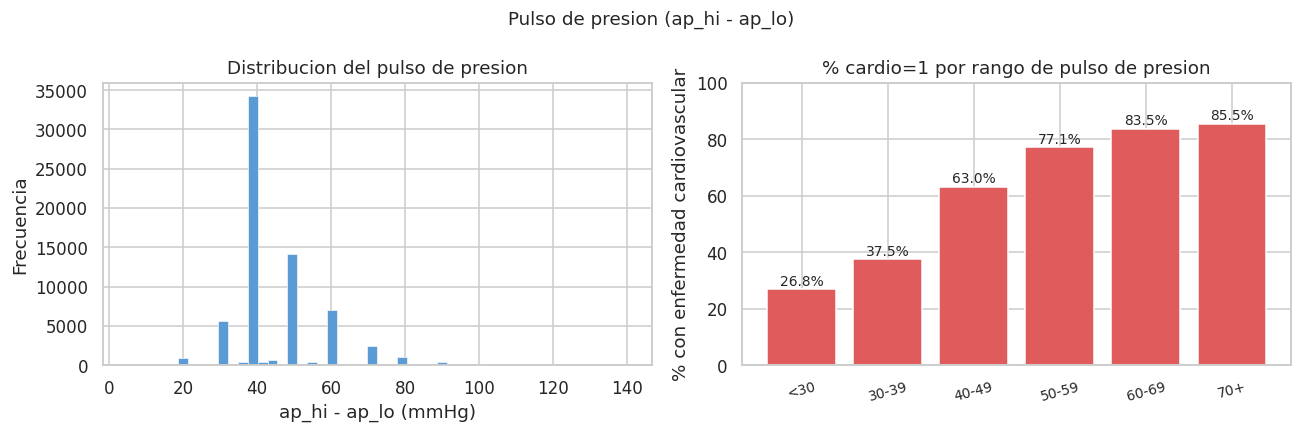

In [6]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

print(f'Pulso de presion — min: {df["pulse_pressure"].min()}, max: {df["pulse_pressure"].max()}, media: {df["pulse_pressure"].mean():.1f}')
print(f'Correlacion con cardio: {df["pulse_pressure"].corr(df["cardio"]):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['pulse_pressure'], bins=50, color='#5b9bd5', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribucion del pulso de presion')
axes[0].set_xlabel('ap_hi - ap_lo (mmHg)')
axes[0].set_ylabel('Frecuencia')

tasas_pp = df.groupby(pd.cut(df['pulse_pressure'],
                              bins=[0,30,40,50,60,70,150],
                              labels=['<30','30-39','40-49','50-59','60-69','70+']))['cardio'].mean()*100
axes[1].bar(range(len(tasas_pp)), tasas_pp.values, color='#e05c5c', edgecolor='white')
axes[1].set_xticks(range(len(tasas_pp)))
axes[1].set_xticklabels(tasas_pp.index, rotation=15, fontsize=9)
axes[1].set_ylim(0, 100)
axes[1].set_title('% cardio=1 por rango de pulso de presion')
axes[1].set_ylabel('% con enfermedad cardiovascular')
for i, v in enumerate(tasas_pp.values):
    axes[1].text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Pulso de presion (ap_hi - ap_lo)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Score de riesgo metabólico (`metabolic_risk`)
Combinamos tres factores de riesgo metabólico en un score sumado de 0 a 3. Cada punto adicional representa un factor de riesgo presente:
- Colesterol elevado o muy elevado (`cholesterol > 1`)
- Glucosa elevada o muy elevada (`gluc > 1`)
- Obesidad (`bmi >= 30`)

El gradiente con cardio es muy limpio y monótono:

| Score | % cardio=1 |
|---|---|
| 0 | 39.6% |
| 1 | 57.5% |
| 2 | 66.5% |
| 3 | 72.7% |

=== Distribución metabolic_risk ===
  Score 0: 37,514 registros — 39.6% cardio=1
  Score 1: 19,322 registros — 57.5% cardio=1
  Score 2: 8,972 registros — 66.5% cardio=1
  Score 3: 2,707 registros — 72.7% cardio=1


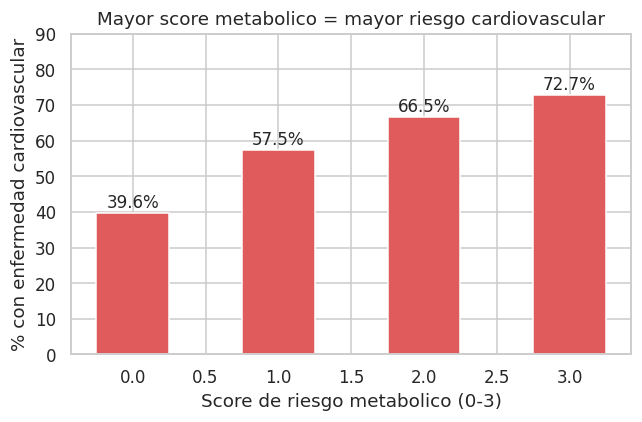

In [7]:
df['metabolic_risk'] = (
    (df['cholesterol'] > 1).astype(int) +
    (df['gluc'] > 1).astype(int) +
    (df['bmi'] >= 30).astype(int)
)

print('=== Distribución metabolic_risk ===')
for k in sorted(df['metabolic_risk'].unique()):
    n = (df['metabolic_risk'] == k).sum()
    tasa = df[df['metabolic_risk']==k]['cardio'].mean()*100
    print(f'  Score {k}: {n:,} registros — {tasa:.1f}% cardio=1')

fig, ax = plt.subplots(figsize=(6, 4))
tasas = df.groupby('metabolic_risk')['cardio'].mean() * 100
ax.bar(tasas.index, tasas.values, color='#e05c5c', edgecolor='white', width=0.5)
ax.set_ylim(0, 90)
ax.set_xlabel('Score de riesgo metabolico (0-3)')
ax.set_ylabel('% con enfermedad cardiovascular')
ax.set_title('Mayor score metabolico = mayor riesgo cardiovascular')
for i, (idx, v) in enumerate(tasas.items()):
    ax.text(idx, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Correlaciones antes y después del feature engineering
Comparamos las correlaciones con `cardio` de las variables originales y las nuevas para confirmar que los features añaden señal útil.

In [8]:
features_originales = ['age', 'bmi', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'gender']
features_nuevos     = ['age_range', 'bp_category', 'pulse_pressure', 'metabolic_risk']

print('=== Correlación con cardio — variables originales ===')
for c in features_originales:
    print(f'  {c:20s}: {df[c].corr(df["cardio"]):+.4f}')

print()
print('=== Correlación con cardio — features nuevos ===')
for c in features_nuevos:
    print(f'  {c:20s}: {df[c].corr(df["cardio"]):+.4f}')

=== Correlación con cardio — variables originales ===
  age                 : +0.2394
  bmi                 : +0.1916
  ap_hi               : +0.4282
  ap_lo               : +0.3401
  cholesterol         : +0.2214
  gluc                : +0.0893
  smoke               : -0.0163
  alco                : -0.0086
  active              : -0.0377
  gender              : +0.0071

=== Correlación con cardio — features nuevos ===
  age_range           : +0.2130
  bp_category         : +0.3498
  pulse_pressure      : +0.3371
  metabolic_risk      : +0.2231


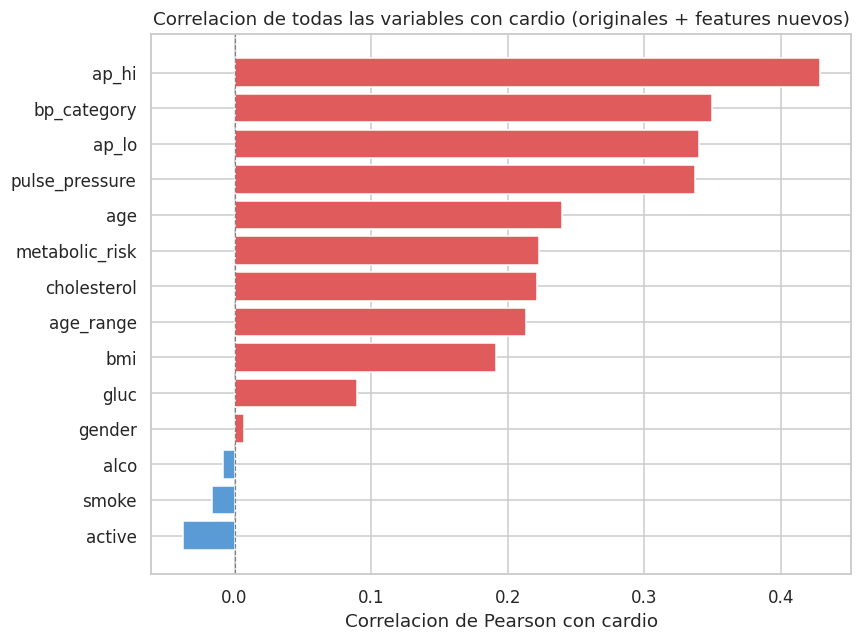

In [9]:
todas = features_originales + features_nuevos
corrs = df[todas].corrwith(df['cardio']).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colores = ['#e05c5c' if v > 0 else '#5b9bd5' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colores, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Correlacion de Pearson con cardio')
ax.set_title('Correlacion de todas las variables con cardio (originales + features nuevos)')
plt.tight_layout()
plt.show()

## 8. Dataset final con features
Revisamos las columnas definitivas. Conservamos las variables originales y añadimos las 4 nuevas. `height` y `weight` se mantienen porque ya están capturadas en `bmi`, pero el modelo puede encontrar señal adicional en ellas.

In [10]:
print('=== Columnas finales ===')
print(df.columns.tolist())
print(f'\nShape: {df.shape}')
print()
df.describe().round(2)

=== Columnas finales ===
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi', 'age_range', 'bp_category', 'pulse_pressure', 'metabolic_risk']

Shape: (68515, 17)



,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,age_range,bp_category,pulse_pressure,metabolic_risk
count,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00,68515.0,68515.00,68515.00,68515.00,68515.00,68515.00,68515.00
mean,53.29,1.35,164.46,74.11,126.68,81.31,1.36,1.23,0.09,0.05,0.8,0.49,27.43,2.86,2.88,45.37,0.66
std,6.76,0.48,7.80,14.26,16.69,9.45,0.68,0.57,0.28,0.22,0.4,0.50,5.19,0.74,0.89,11.66,0.85
min,29.60,1.00,140.00,30.00,60.00,40.00,1.00,1.00,0.00,0.00,0.0,0.00,10.70,1.00,1.00,5.00,0.00
25%,48.30,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.00,23.90,2.00,3.00,40.00,0.00
50%,53.90,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.00,26.30,3.00,3.00,40.00,0.00
75%,58.40,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.00,30.10,3.00,3.00,50.00,1.00
max,64.90,2.00,207.00,180.00,240.00,182.00,3.00,3.00,1.00,1.00,1.0,1.00,68.30,4.00,4.00,140.00,3.00


## 9. Guardar `cardio_features.csv`
Guardamos en Drive y descargamos la copia local para VSCode. Este archivo es la entrada para `04_model_training.ipynb`.

In [11]:
df.to_csv(FEATURES_PATH, index=False)
print(f'✓ Guardado en Drive: {FEATURES_PATH}')
print(f'  Registros: {len(df):,}   Columnas: {df.shape[1]}')

✓ Guardado en Drive: /content/drive/MyDrive/cardio-backend/data/processed/cardio_features.csv
  Registros: 68,515   Columnas: 17


In [12]:
from google.colab import files
df.to_csv('cardio_features.csv', index=False)
files.download('cardio_features.csv')
print('✓ Descarga iniciada — guarda el archivo en cardio-backend/data/processed/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descarga iniciada — guarda el archivo en cardio-backend/data/processed/


## 10. Resumen de features construidos

| Feature | Tipo | Justificación clínica |
|---|---|---|
| `age_range` | Ordinal 1–4 | Captura la aceleración no lineal del riesgo por décadas |
| `bp_category` | Ordinal 1–4 | Clasificación AHA — el feature con gradiente más limpio (22% → 84%) |
| `pulse_pressure` | Numérico | Indicador de rigidez arterial, correlación 0.337 con cardio |
| `metabolic_risk` | Ordinal 0–3 | Score sumado de obesidad + colesterol + glucosa |

### Lo que NO se añadió y por qué
- Variables de interacción `smoke × alco`: ambas tienen señal casi nula por el subregistro documentado en el EDA — crear interacciones entre ruido solo añade ruido.
- Transformaciones polinómicas de `ap_hi`: Random Forest y XGBoost manejan relaciones no lineales de forma nativa — no es necesario.

### Siguiente paso
`04_model_training.ipynb` — entrenamiento de Random Forest y XGBoost con `cardio_features.csv`.